Phan Hoài Bảo Khang
2045240120

# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
...

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)

# print("Các cột còn lại:", list(df.columns))

# TODO 1a: in tỷ lệ missing của tất cả các cột
print("--- TỶ LỆ MISSING TRÊN TOÀN BỘ DATAFRAME ---")
missing_ratio = df.isnull().mean()
print(missing_ratio)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# Lọc danh sách cột để chỉ bỏ những cột thực sự tồn tại trong df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
cols_to_drop = [c for c in leaky if c in df.columns]

df = df.drop(columns=cols_to_drop)
print("\nCác cột còn lại:", list(df.columns))

--- TỶ LỆ MISSING TRÊN TOÀN BỘ DATAFRAME ---
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột alive (giá trị yes/no) bản chất là một phiên bản biểu diễn bằng chữ của biến mục tiêu survived (giá trị 1/0). Nếu giữ lại cột này trong ma trận đặc trưng $X$, mô hình sẽ dễ dàng thiết lập mối quan hệ tương quan $100\%$ trực tiếp giữa alive và survived. Khi đó, mô hình đạt độ chính xác tuyệt đối (Accuracy ~100%) một cách "gian lận" dựa trên thông tin đã biết trước của nhãn mục tiêu, dẫn đến hiện tượng rò rỉ dữ liệu (data leakage) nghiêm trọng và mô hình sẽ mất hoàn toàn khả năng dự đoán trên dữ liệu thực tế nơi nhãn mục tiêu chưa được cung cấp.


---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
...

# 1. Shape dữ liệu
print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("Biến mục tiêu (Target): survived\n")

# 2. Kiểm tra thông tin kiểu dữ liệu và giá trị non-null
print("--- THÔNG TIN DF.INFO() ---")
df.info()

# 3. Thống kê mô tả cho biến số
print("\n--- THỐNG KÊ BIẾN SỐ ---")
print(df.describe())

# 4. Thống kê mô tả cho biến phân loại
print("\n--- THỐNG KÊ BIẾN PHÂN LOẠI ---")
print(df.describe(include=['object', 'category']))

Kích thước dữ liệu: 891 dòng, 8 cột
Biến mục tiêu (Target): survived

--- THÔNG TIN DF.INFO() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

--- THỐNG KÊ BIẾN SỐ ---
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min    

**Trả lời 2 (biến số vs biến phân loại):**

Dựa vào kết quả kiểm tra df.info(), ta phân loại các cột còn lại như sau:
    Biến số (Numerical features): age (float64), sibsp (int64), parch (int64), fare (float64).
    Biến số có tính thứ tự (Ordinal feature): pclass (int64) - đóng vai trò là số hạng vé/hạng khoang (1 < 2 < 3).
    Biến phân loại (Categorical features): sex (object/category), embarked (object/category).  

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
...
print("--- BẢNG THỐNG KÊ GIÁ TRỊ THIẾU ---")
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Phần trăm thiếu (%)': missing_pct
})
# Chỉ hiển thị các cột có missing value
print(missing_table[missing_table['Số lượng thiếu'] > 0])

--- BẢNG THỐNG KÊ GIÁ TRỊ THIẾU ---
          Số lượng thiếu  Phần trăm thiếu (%)
age                  177            19.865320
embarked               2             0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | ~19.87% | Điền giá trị trung vị (median) | Tỷ lệ thiếu ở mức vừa phải. Sử dụng median an toàn và bền vững hơn mean do phân phối của tuổi tác thường bị lệch và nhạy cảm với các outlier (ví dụ: hành khách lớn tuổi cụ thể hoặc trẻ sơ sinh). |
| embarked | ~0.22% | Điền giá trị yếu vị (mode) | Đây là biến phân loại phân định cảng lên tàu và chỉ thiếu duy nhất 2 mẫu. Phương pháp điền giá trị xuất hiện phổ biến nhất (most_frequent) là tối ưu và đơn giản nhất. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    # Loại bỏ NaN trước khi tính toán z-score để đảm bảo tính chính xác
    s_clean = s.dropna()
    z_scores = np.abs(stats.zscore(s_clean))
    return (z_scores > nguong).sum()

for col in ["age", "fare"]:
    out_iqr = dem_outlier_iqr(df[col])
    out_z = dem_outlier_zscore(df[col])
    print(f"Cột '{col}': Phát hiện {out_iqr} outlier theo IQR | {out_z} outlier theo Z-score")

Cột 'age': Phát hiện 11 outlier theo IQR | 2 outlier theo Z-score
Cột 'fare': Phát hiện 116 outlier theo IQR | 20 outlier theo Z-score


**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

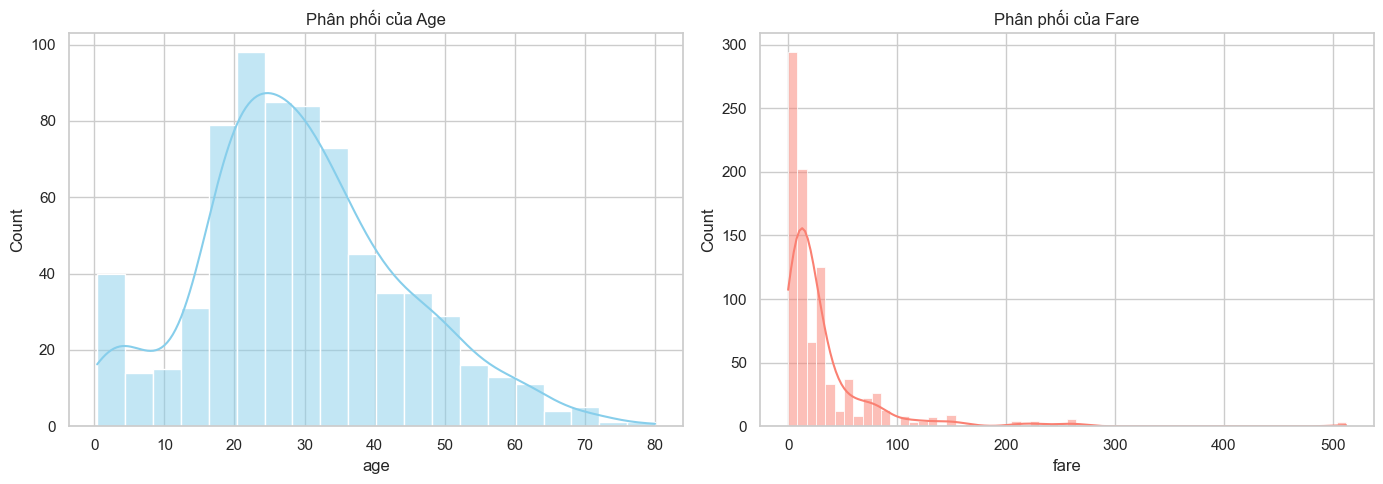

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Age')
sns.histplot(df['fare'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối của Fare')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_25572\2969319125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')


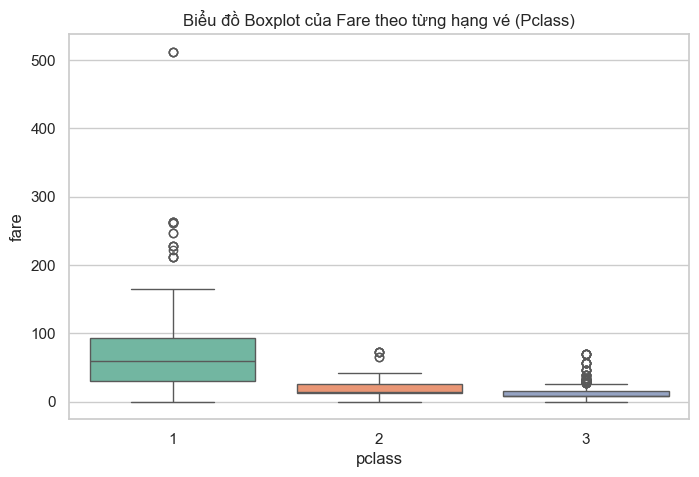

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')
plt.title('Biểu đồ Boxplot của Fare theo từng hạng vé (Pclass)')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_25572\449506175.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Blues_d')
C:\Users\admin\AppData\Local\Temp\ipykernel_25572\449506175.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], palette='Oranges_d')


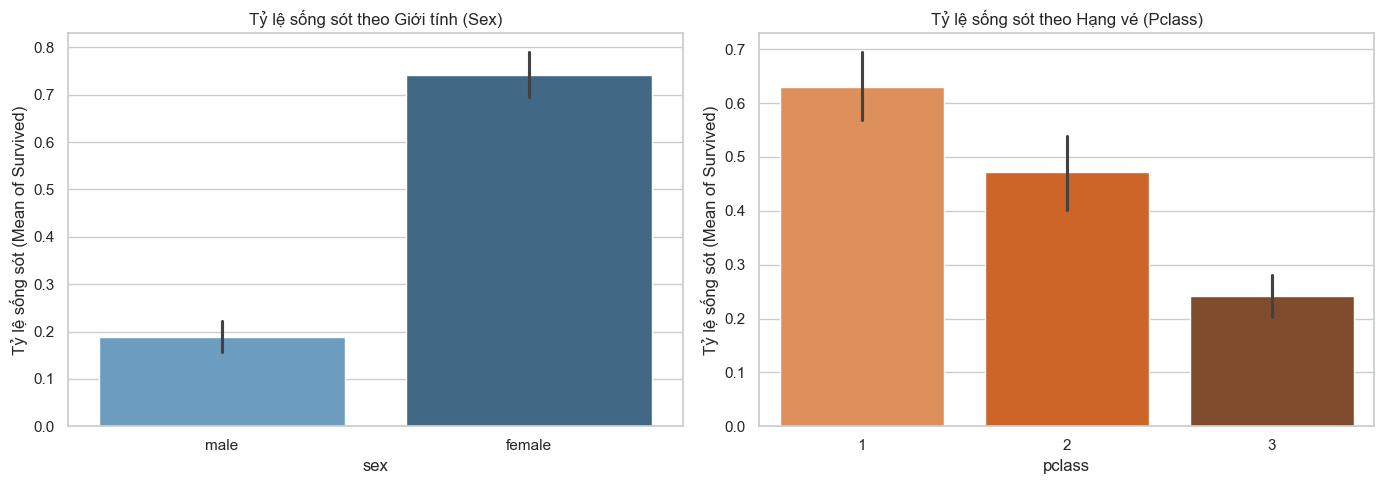

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Blues_d')
axes[0].set_title('Tỷ lệ sống sót theo Giới tính (Sex)')
axes[0].set_ylabel('Tỷ lệ sống sót (Mean of Survived)')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé (Pclass)')
axes[1].set_ylabel('Tỷ lệ sống sót (Mean of Survived)')
plt.tight_layout()
plt.show()

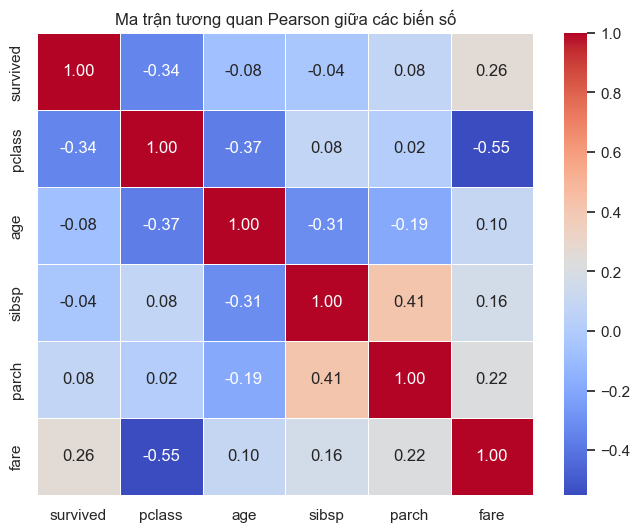

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan Pearson giữa các biến số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Biến age có phân phối gần chuẩn nhưng hơi lệch phải nhẹ (chứa nhiều hành khách trẻ tuổi và trung niên). Ngược lại, biến fare lệch phải cực kỳ nghiêm trọng (skewed right), phần lớn hành khách mua vé giá rẻ, trong khi có một số rất ít mua vé cực kỳ đắt đỏ tạo nên chiếc đuôi dài về phía bên phải.
- Boxplot: Giá vé fare phân hóa rất mạnh theo pclass. Hạng 1 (pclass=1) có dải giá vé rất rộng và chứa lượng lớn outlier cực cao vượt trội hoàn toàn so với hạng 2 và hạng 3. Điều này củng cố luận điểm rằng outlier ở đây là giá trị thực tế của giới thượng lưu.
- Bar survival: Có sự chênh lệch rõ rệt về cơ hội sống sót. Nữ giới (female) có tỷ lệ sống sót vượt trội (>70%) so với nam giới (~20%), phản ánh quy tắc cứu nạn "phụ nữ và trẻ em được ưu tiên". Đồng thời, hành khách hạng 1 có tỷ lệ sống sót cao nhất (~60%), giảm dần xuống hạng 2 và thấp nhất là hạng 3 (~25%), chứng minh vị thế xã hội ảnh hưởng trực tiếp đến cơ hội sinh tồn.
- Heatmap: Cặp biến có tương quan tuyến tính nghịch mạnh nhất là fare và pclass (-0.55), điều này hoàn toàn hợp lý vì số hạng vé càng nhỏ (Hạng 1) thì giá vé càng cao. Biến số có tương quan thuận rõ nhất với survived là fare (0.26) và tương quan nghịch rõ nhất là pclass (-0.34). 

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify


# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
# X_train, X_val, y_train, y_val = train_test_split(...)

# print("Train/Val/Test:", ...)
# in tỷ lệ survived từng tập


X = df.drop(columns=['survived'])
y = df['survived']

# Chia tập dữ liệu thành (Train + Val) và Test (15%)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Chia tập (Train + Val) thành Train (70%) và Val (15%)
# Tỷ lệ tách 0.1765 tương đương với 15% tổng thể ban đầu (0.15 / 0.85 ≈ 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=42
)

print(f"Kích thước tập Train: {X_train.shape}, Tỷ lệ Survived: {y_train.mean():.4f}")
print(f"Kích thước tập Val:   {X_val.shape}, Tỷ lệ Survived: {y_val.mean():.4f}")
print(f"Kích thước tập Test:  {X_test.shape}, Tỷ lệ Survived: {y_test.mean():.4f}")

Kích thước tập Train: (623, 7), Tỷ lệ Survived: 0.3836
Kích thước tập Val:   (134, 7), Tỷ lệ Survived: 0.3881
Kích thước tập Test:  (134, 7), Tỷ lệ Survived: 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # Điền giá trị thiếu bằng median
    ("scaler", RobustScaler())                     # Dùng RobustScaler chống nhiễu do outlier từ fare
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # Điền phân loại bằng mode
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # Mã hóa one-hot
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols) # Giữ nguyên pclass vì đã có thứ tự dạng số
])

# Học các tham số (fit) CHỈ từ tập X_train để ngăn chặn rò rỉ thông tin
preprocess.fit(X_train)

# Áp dụng chuyển đổi (transform) lên cả 3 tập độc lập
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)

print("Kích thước ma trận sau tiền xử lý:", X_train_t.shape)
print("Danh sách các cột đặc trưng mới:\n", list(preprocess.get_feature_names_out()))

Kích thước ma trận sau tiền xử lý: (623, 10)
Danh sách các cột đặc trưng mới:
 ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Khi ta fit mô hình tiền xử lý, hệ thống sẽ tính toán các tham số thống kê nội tại của tập dữ liệu như giá trị trung vị (median của age) hoặc các phân vị Q1, Q3 để tiến hành co giãn dữ liệu. Nếu ta thực hiện fit trên toàn bộ tập dữ liệu (bao gồm cả Validation và Test), vô hình trung thông tin phân phối từ tương lai của tập Test đã rò rỉ vào quá trình chuẩn hóa tập Train. Việc chỉ fit trên Train đảm bảo các tham số này hoàn toàn cô lập, tập Validation và Test được giữ nguyên trạng như một nguồn dữ liệu độc lập chưa từng biết tới, phản ánh chính xác hiệu năng thực tế của mô hình sau này.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print("--- PHÂN PHỐI LỚP TARGET SURVIVED ---")
print(df['survived'].value_counts(normalize=True))

--- PHÂN PHỐI LỚP TARGET SURVIVED ---
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**


1. Biến mục tiêu survived có xảy ra hiện tượng mất cân bằng dữ liệu (Imbalanced Data) nhưng ở mức vừa phải / nhẹ (~61.6% tử vong và ~38.4% sống sót), không quá cực đoan như bài toán phát hiện gian lận thẻ tín dụng hay y sinh.
2. Độ chính xác Accuracy có thể bị đánh lừa khi tập dữ liệu mất cân bằng nghiêm trọng. Ví dụ nếu tỷ lệ không sống sót lên đến 95%, một mô hình lười biếng chỉ cần luôn dự đoán là "không sống sót" vẫn dễ dàng đạt 95% Accuracy, nhưng hoàn toàn mất đi khả năng nhận diện những ca sống sót (vốn là nhóm thiểu số quan trọng).
3. Với bài toán Titanic, hệ số F1-Score nên được ưu tiên lựa chọn. Vì tập dữ liệu có sự chênh lệch lớp nhẹ, F1-Score (trung bình điều hòa giữa Precision và Recall) sẽ giúp tối ưu hóa đồng thời khả năng giảm thiểu việc dự đoán sai hành khách sống sót (Precision) cũng như bỏ sót những người thực tế sống sót (Recall), mang lại cái nhìn toàn diện và khách quan hơn Accuracy. 

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**
1. Yếu tố tương quan mạnh nhất: Đặc trưng có tác động phân hóa mạnh mẽ nhất tới khả năng sinh tồn là Giới tính (sex). Nữ giới sở hữu cơ hội sống sót vượt trội trên 70% so với nam giới (~20%). Bên cạnh đó, số liệu tương quan Pearson chỉ ra hạng vé pclass tỉ lệ nghịch mạnh nhất với khả năng sống (-0.34).
2. Xử lý giá trị thiếu (Missing values): Cột chứa lượng giá trị thiếu nhiều nhất sau khi lọc là age (~19.87%). Cột này được xử lý bằng cách điền giá trị trung vị (median) được tính toán độc lập từ tập huấn luyện để tránh data leakage và đảm bảo độ bền vững trước outlier.
3. Mất cân bằng và Metric: Biến mục tiêu survived có sự chênh lệch nhẹ (~62% vs ~38%). Sự mất cân bằng này làm giảm tính tin cậy của chỉ số Accuracy và định hướng việc sử dụng F1-Score làm hệ số tối ưu cốt lõi.
4. Kỹ thuật Tiền xử lý (Scaling & Encoding): Các biến số liên tục (age, fare) mang đặc trưng lệch dữ liệu cao và nhiều outlier nên bắt buộc cần áp dụng kỹ thuật RobustScaler để co giãn dựa trên phân vị. Các biến định danh phân loại (sex, embarked) được đưa qua pipeline OneHotEncoder để chuyển đổi cấu trúc sang định dạng nhị phân ma trận thưa mà thuật toán Machine Learning có thể tiếp nhận.
5. Điểm thú vị phát hiện từ dữ liệu: Sự kết hợp đồng thời giữa yếu tố sinh học và vị thế xã hội: Mặc dù hành khách hạng 3 chiếm số lượng đông đảo nhất trên tàu, cơ hội sống sót của họ lại thấp nhất (~25%). Tuy nhiên, nếu một hành khách thuộc hạng 3 nhưng là Nữ giới, cơ hội sinh tồn của họ vẫn cao hơn rất nhiều so với một hành khách Nam giới dù người đàn ông đó mua vé hạng 1 xa xỉ.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

--- HƯỚNG 1: FEATURE ENGINEERING ---


C:\Users\admin\AppData\Local\Temp\ipykernel_25572\746501640.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df_bonus, x='family_size', y='survived', palette='crest')


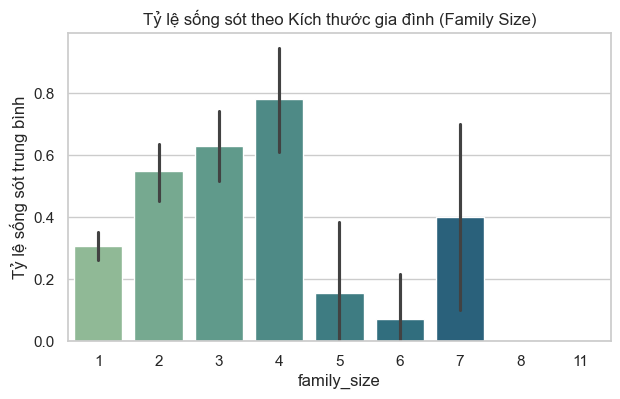

Lưu ý: Dataset hiện tại từ Seaborn không có cột 'name' nên bỏ qua bước trích xuất Title.


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- HƯỚNG 1: FEATURE ENGINEERING ---")

# 1. Tạo đặc trưng family_size (kích thước gia đình)
# Công thức: số anh chị em/vợ chồng + số cha mẹ/con cái + bản thân hành khách
X_train_bonus = X_train.copy()
X_train_bonus['family_size'] = X_train_bonus['sibsp'] + X_train_bonus['parch'] + 1

# 2. Kiểm tra mối tương quan của family_size với survived (sử dụng y_train)
train_df_bonus = X_train_bonus.copy()
train_df_bonus['survived'] = y_train

plt.figure(figsize=(7, 4))
sns.barplot(data=train_df_bonus, x='family_size', y='survived', palette='crest')
plt.title('Tỷ lệ sống sót theo Kích thước gia đình (Family Size)')
plt.ylabel('Tỷ lệ sống sót trung bình')
plt.show()

# 3. Trích xuất đặc trưng 'title' từ tên nếu cột 'name' tồn tại trong dữ liệu gốc
if 'name' in df.columns:
    # Biểu thức chính quy tách Mr, Mrs, Miss... nằm trước dấu chấm ở cột name
    df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Gom nhóm các danh xưng hiếm gặp vào nhóm 'Rare' để tránh overfitting
    rare_titles = df['title'].value_counts()[df['title'].value_counts() < 10].index
    df['title'] = df['title'].replace(rare_titles, 'Rare')
    
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x='title', y='survived', palette='muted')
    plt.title('Tỷ lệ sống sót theo Danh xưng (Title)')
    plt.show()
else:
    print("Lưu ý: Dataset hiện tại từ Seaborn không có cột 'name' nên bỏ qua bước trích xuất Title.")

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
